# Optuna - подбор гиперпараметров модели

Данные из предыдущей задачи, но в варианте после обработки

Предсказываем среднюю цену за сутки проживания в евро

In [30]:
# Установка зависимостей
!pip install -r requirements.txt -q

In [31]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import optuna

In [32]:
# Загрузка датасета с кешированием на диске
try:
    df = pd.read_csv('./2. hotel.csv')
    print('Dataset found locally.')
except:
    print('Dataset not found locally.')
    df = pd.read_csv('https://code.s3.yandex.net/datasets/Hotel_Reservations.csv')
    df.to_csv('./2. hotel.csv')

Dataset found locally.


In [33]:
df.head(5)

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,...,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,is_vip_guest,no_of_adults_has_outlier,no_of_children_has_outlier,no_of_weekend_nights_has_outlier,no_of_week_nights_has_outlier
0,INN05072,2,0,1.0,3.0,Meal Plan 1,NaN,Room_Type 4,27,2018,...,0,0,96.90,2,False,No,0,0,0,0
1,INN22558,2,0,2.0,1.0,Meal Plan 1,0.0,Room_Type 1,177,2018,...,0,0,90.90,0,False,No,0,0,0,0
2,INN04464,2,0,0.0,1.0,Meal Plan 1,0.0,Room_Type 1,0,2018,...,0,0,109.00,0,False,No,0,0,0,0
3,INN02174,2,0,0.0,2.0,Meal Plan 1,0.0,Room_Type 4,65,2018,...,0,0,149.40,1,False,No,0,0,0,0
4,INN26110,3,0,1.0,5.0,Meal Plan 1,0.0,Room_Type 4,15,2018,...,0,0,87.33,1,False,No,1,0,0,0


# Базовая модель

In [34]:
from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score

# Группы признаков для модели
binary_features = ['is_vip_guest']
categorical_non_binary = ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']
numerical_with_nan = ['no_of_weekend_nights', 'no_of_week_nights', 'required_car_parking_space']

# Разделение данных
X = df.drop(["Booking_ID", "avg_price_per_room", "booking_status"], axis=1)
y = df["avg_price_per_room"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Создаём ColumnTransformer с обработкой разных типов признаков
transformers_list = []

# 1. Бинарные признаки - OneHotEncoder с drop="first": убираем первый столбец каждой категории, чтобы избежать дамми-ловушки
if binary_features:
    transformers_list.append(("binary", OneHotEncoder(sparse_output=False, handle_unknown="ignore", drop="first"), binary_features))

# 2. Категориальные небинарные - OneHotEncoder
if categorical_non_binary:
    transformers_list.append(
        ("categorical", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), categorical_non_binary)
    )

# 3. Числовые с NaN - SimpleImputer с -999999
if numerical_with_nan:
    transformers_list.append(
        ("imputer", SimpleImputer(fill_value=-999999), numerical_with_nan)
    )

preprocessor = ColumnTransformer(
    transformers=transformers_list,
    remainder="passthrough",
)

# Определяем пайплайн с базовой моделью
model_base = DecisionTreeRegressor(
    random_state=42,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10
)

pipeline_base = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model_base)
])

# Настраиваем кросс-валидацию
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Набор метрик для оценки
scoring = {
    "MAE": make_scorer(mean_absolute_error),
    "MSE": make_scorer(mean_squared_error),
    "R2": make_scorer(r2_score)
}

# Оцениваем качество модели на кросс-валидации
cv_results_base = cross_validate(
    pipeline_base,
    X_train,
    y_train,
    scoring=scoring,
    cv=cv
)

# Выводим результаты
for metric, scores in cv_results_base.items():
    if "test" in metric:
        print(f"Среднее значение {metric.replace('test_', '')}: {scores.mean():.3f}")

for metric, scores in cv_results_base.items():
    if "test" in metric:
        print(f"Стандартное отклонение {metric.replace('test_', '')}: {scores.std():.4f}")

Среднее значение MAE: 14.217
Среднее значение MSE: 447.245
Среднее значение R2: 0.629
Стандартное отклонение MAE: 0.2259
Стандартное отклонение MSE: 32.2830
Стандартное отклонение R2: 0.0285


In [35]:
preprocessor.fit_transform(X_train, y_train)

array([[0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]], shape=(19518, 34))

# Подбор гиперпараметров через Optuna

In [36]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeRegressor

def objective(trial: optuna.trial.Trial):
    # Пространство поиска гиперпараметров
    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 50),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
    }

    model = DecisionTreeRegressor(random_state=42, **params)
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scorer = make_scorer(mean_absolute_error)

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scorer
    )

    mean_score = scores.mean()

    trial.report(mean_score, step=0)
    if trial.should_prune():
        raise optuna.TrialPruned()

    return mean_score

# Запуск исследования
# Фиксируем сид через самплер
sampler = optuna.samplers.TPESampler(seed=42)

study = optuna.create_study(
    direction="minimize",
    sampler=sampler,
)
study.optimize(objective, n_trials=15, show_progress_bar=True)

[I 2026-05-27 15:45:55,472] A new study created in memory with name: no-name-e042af1b-b584-42a5-aec5-33a782f603eb


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-05-27 15:45:55,687] Trial 0 finished with value: 16.994976759488274 and parameters: {'max_depth': 7, 'min_samples_split': 48, 'min_samples_leaf': 15}. Best is trial 0 with value: 16.994976759488274.
[I 2026-05-27 15:45:55,935] Trial 1 finished with value: 14.129025407703548 and parameters: {'max_depth': 10, 'min_samples_split': 9, 'min_samples_leaf': 4}. Best is trial 1 with value: 14.129025407703548.
[I 2026-05-27 15:45:56,086] Trial 2 finished with value: 20.498730288435368 and parameters: {'max_depth': 3, 'min_samples_split': 44, 'min_samples_leaf': 13}. Best is trial 1 with value: 14.129025407703548.
[I 2026-05-27 15:45:56,347] Trial 3 finished with value: 13.47471625155742 and parameters: {'max_depth': 12, 'min_samples_split': 3, 'min_samples_leaf': 20}. Best is trial 3 with value: 13.47471625155742.
[I 2026-05-27 15:45:56,626] Trial 4 finished with value: 12.30087399829111 and parameters: {'max_depth': 13, 'min_samples_split': 12, 'min_samples_leaf': 4}. Best is trial 4 w

In [37]:
# Лучшие гиперпараметры и качество
best_params = study.best_params
print("Лучшие гиперпараметры:", best_params)
best_value = study.best_value
print("Лучшее среднее значение MAE на кросс-валидации:", best_value)

Лучшие гиперпараметры: {'max_depth': 15, 'min_samples_split': 28, 'min_samples_leaf': 7}
Лучшее среднее значение MAE на кросс-валидации: 11.853777773344884


# Сравнение базовой и оптимизированной моделей

In [39]:
# Определяем пайплайн с оптимизированной моделью
model_best = DecisionTreeRegressor(**best_params, random_state=42)

pipeline_best = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model_best)
])

# Набор метрик для оценки
scoring = {
    "MAE": make_scorer(mean_absolute_error),
    "MSE": make_scorer(mean_squared_error),
    "R2": make_scorer(r2_score)
}

# Оцениваем качество модели на кросс-валидации
cv_results_best = cross_validate(
    pipeline_best,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

# Выводим результаты
for metric, scores in cv_results_best.items():
    if "test" in metric:
        print(f"Среднее значение {metric.replace('test_', '')}: {scores.mean():.3f}")

for metric, scores in cv_results_best.items():
    if "test" in metric:
        print(f"Стандартное отклонение {metric.replace('test_', '')}: {scores.std():.4f}")

Среднее значение MAE: 11.854
Среднее значение MSE: 374.984
Среднее значение R2: 0.689
Стандартное отклонение MAE: 0.1305
Стандартное отклонение MSE: 31.4000
Стандартное отклонение R2: 0.0274


# Обучение финальной модели на всей тестовой выборке

In [41]:
pipeline_best.fit(X_train, y_train)

# Получите предсказания
y_pred = pipeline_best.predict(X_test)

# Рассчитайте метрики
print("MAE на тестовой выборке:", round(mean_absolute_error(y_test, y_pred),3))
print("MSE на тестовой выборке:", round(mean_squared_error(y_test, y_pred),3))
print("R2 на тестовой выборке:", round(r2_score(y_test, y_pred),3))

MAE на тестовой выборке: 11.686
MSE на тестовой выборке: 355.106
R2 на тестовой выборке: 0.693


# Оценка важности признаков

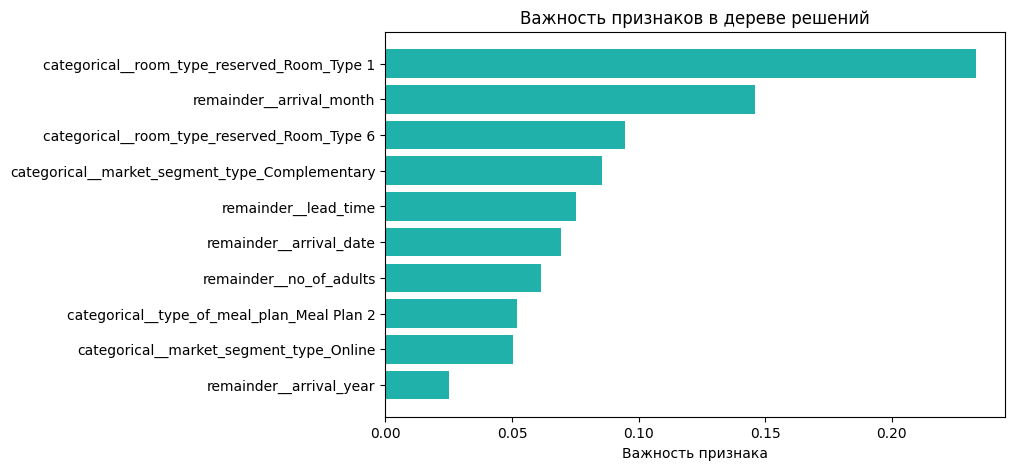

In [42]:
# Создаём таблицу с feature importance
feature_importance = pd.DataFrame(
    {
        "feature": pipeline_best.named_steps["preprocessor"].get_feature_names_out(),
        "importance": pipeline_best.named_steps["model"].feature_importances_
    }
).sort_values('importance', ascending=False)

# Визуализация важности для топ-10 признаков
top_10_feature_names = feature_importance[:10]['feature']
top_10_feature_importance = feature_importance[:10]['importance']

plt.figure(figsize=(8, 5))
plt.barh(top_10_feature_names, top_10_feature_importance, color='lightseagreen')
plt.xlabel('Важность признака')
plt.title('Важность признаков в дереве решений')
plt.gca().invert_yaxis()
plt.show()